In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
pd.read_csv(r'C:\Users\juanb\Desktop\IronHack\labs-eda\amz_uk.csv')

C:\Users\juanb\AppData\Local\Temp\ipykernel_24460\1564397268.py:6: DtypeWarning: Columns (0: uid, 1: isBestSeller) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(r'C:\Users\juanb\Desktop\IronHack\labs-eda\amz_uk.csv')


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099.0,23.99,True,0.0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308.0,21.99,False,0.0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205.0,31.99,False,0.0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881.0,17.99,False,0.0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0.0,97.99,False,0.0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0.0,52.99,False,0.0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404.0,79.99,False,0.0,Motorbike Clothing
2443650,2828593,B08P3W9B3T,RIDEX CJ223 Motorcycle Motorbike Jacket Armour...,4.5,34.0,53.99,False,0.0,Motorbike Clothing


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r'C:\Users\juanb\Desktop\IronHack\labs-eda\amz_uk.csv', low_memory=False)

print(df.shape)
print(df['isBestSeller'].value_counts(dropna=False).head(10))
print(df['isBestSeller'].dtype)

(2443652, 9)
isBestSeller
False    2435671
True        7980
NaN            1
Name: count, dtype: int64
object


In [3]:
df = df.dropna(subset=['stars', 'price', 'category', 'isBestSeller'])
df = df[df['price'] > 0]

print(f"Filas tras limpieza: {df.shape[0]:,}")
print(df['isBestSeller'].value_counts())
print(df['isBestSeller'].dtype)
print(df['isBestSeller'].value_counts())

Filas tras limpieza: 2,443,631
isBestSeller
False    2435653
True        7978
Name: count, dtype: int64
object
isBestSeller
False    2435653
True        7978
Name: count, dtype: int64


In [4]:
crosstab= pd.crosstab(df['isBestSeller'], df['category'])
crosstab

category,3D Printers,3D Printing & Scanning,Abrasive & Finishing Products,Action Cameras,Adapters,Agricultural Equipment & Supplies,Alexa Built-In Devices,Art & Craft Supplies,Arts & Crafts,Baby,...,Uninterruptible Power Supply Units & Accessories,Vacuums & Floorcare,Vases,"Water Coolers, Filters & Cartridges",Wearable Technology,Wind Instruments,Window Treatments,Women,Women's Sports & Outdoor Shoes,eBook Readers & Accessories
isBestSeller,,,,,,,,,,,,,,,,,,,,,
False,247,4065,245,1696,251,8421,106,253,9319,14709,...,3652,6919,250,186,8876,243,234,17559,1939,246
True,1,2,5,1,3,109,1,5,230,341,...,1,26,0,1,30,7,5,213,20,0


In [5]:
crosstab_pct= pd.crosstab(df['isBestSeller'], df['category'], normalize='columns')
crosstab_pct

category,3D Printers,3D Printing & Scanning,Abrasive & Finishing Products,Action Cameras,Adapters,Agricultural Equipment & Supplies,Alexa Built-In Devices,Art & Craft Supplies,Arts & Crafts,Baby,...,Uninterruptible Power Supply Units & Accessories,Vacuums & Floorcare,Vases,"Water Coolers, Filters & Cartridges",Wearable Technology,Wind Instruments,Window Treatments,Women,Women's Sports & Outdoor Shoes,eBook Readers & Accessories
isBestSeller,,,,,,,,,,,,,,,,,,,,,
False,0.995968,0.999508,0.98,0.999411,0.988189,0.987222,0.990654,0.98062,0.975914,0.977342,...,0.999726,0.996256,1.0,0.994652,0.996631,0.972,0.979079,0.988015,0.989791,1.0
True,0.004032,0.000492,0.02,0.000589,0.011811,0.012778,0.009346,0.01938,0.024086,0.022658,...,0.000274,0.003744,0.0,0.005348,0.003369,0.028,0.020921,0.011985,0.010209,0.0


In [6]:
bestseller_pct = crosstab_pct.loc[True].sort_values(ascending=False)
bestseller_pct.head(10)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057692
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Mirrors                           0.028000
Wind Instruments                  0.028000
Name: True, dtype: float64

In [9]:
chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)
print(f"Chi2:{chi2:.2f}")
print(f"P-value:{p_value:.4f}")
print(f"Grados de libertad:{dof}")

Chi2:36550.56
P-value:0.0000
Grados de libertad:295


In [10]:
n= df.shape[0]
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape)-1)))
print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1223


Chi-square — SÍ existe relación entre categoría y best-seller (p-valor casi 0)
Cramér's V: 0.1223 — pero esa relación es débil

En términos de negocio: la categoría influye en si un producto es best-seller, pero no es el factor determinante. Hay otros factores (precio, reviews, marketing) que probablemente explican mejor por qué un producto se convierte en best-seller.

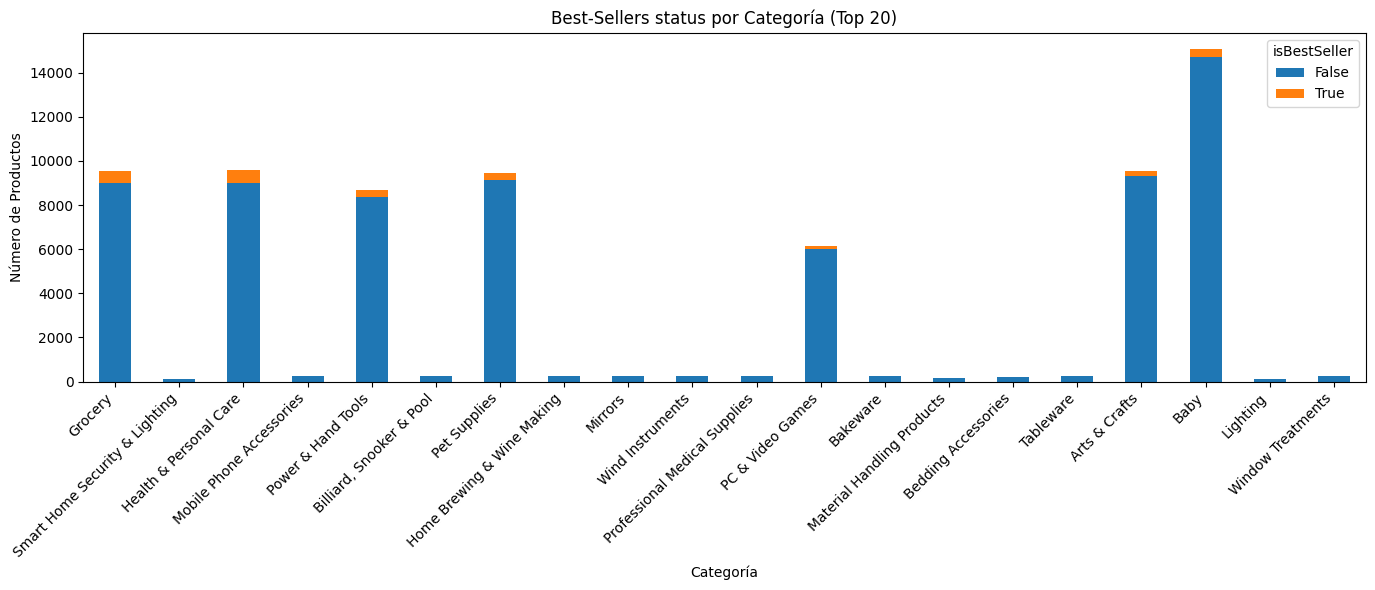

In [12]:
# Top 20 ategorías por proporción de best-sellers
top_20_categories = bestseller_pct.head(20).index

#Filtrar crosstab

crosstab_top_20 = crosstab[top_20_categories]

# Gráfico
crosstab_top_20.T.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Best-Sellers status por Categoría (Top 20)')
plt.xlabel('Categoría')
plt.ylabel('Número de Productos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part 1: Conclusiones – Best-Seller Trends

**Crosstab y proporciones:**
- Solo el 0.3% de los productos (7,978 de 2,443,631) son best-sellers en Amazon UK
- Las categorías con mayor proporción de best-sellers son Grocery (5.8%), Smart Home Security & Lighting (5.8%) y Health & Personal Care (5.8%)
- Categorías como Vases o eBook Readers no tienen ningún best-seller

**Test Chi-square:**
- Chi2: 36,550.56 | P-valor: 0.0000 | Grados de libertad: 295
- Rechazamos H0 — la categoría SÍ influye en el best-seller status

**Cramér's V: 0.1223**
- La asociación entre categoría y best-seller es estadísticamente significativa pero débil
- La categoría no es el factor determinante — otros factores como precio, reviews o marketing probablemente explican mejor el best-seller status

**Visualización:**
- El stacked bar chart confirma visualmente el desbalance extremo entre productos normales y best-sellers en todas las categorías
- Las categorías de consumo frecuente (Grocery, Health, Pet Supplies) tienen proporcionalmente más best-sellers, lo que tiene sentido por su alta rotación

In [13]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR= Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print(f"Filas originales: {df.shape[0]:,}")
print(f"Filas sin outliers: {df_no_outliers.shape[0]:,}")
print(f"Outliers eliminados: {df.shape[0] - df_no_outliers.shape[0]:,}")

Filas originales: 2,443,631
Filas sin outliers: 2,115,943
Outliers eliminados: 327,688


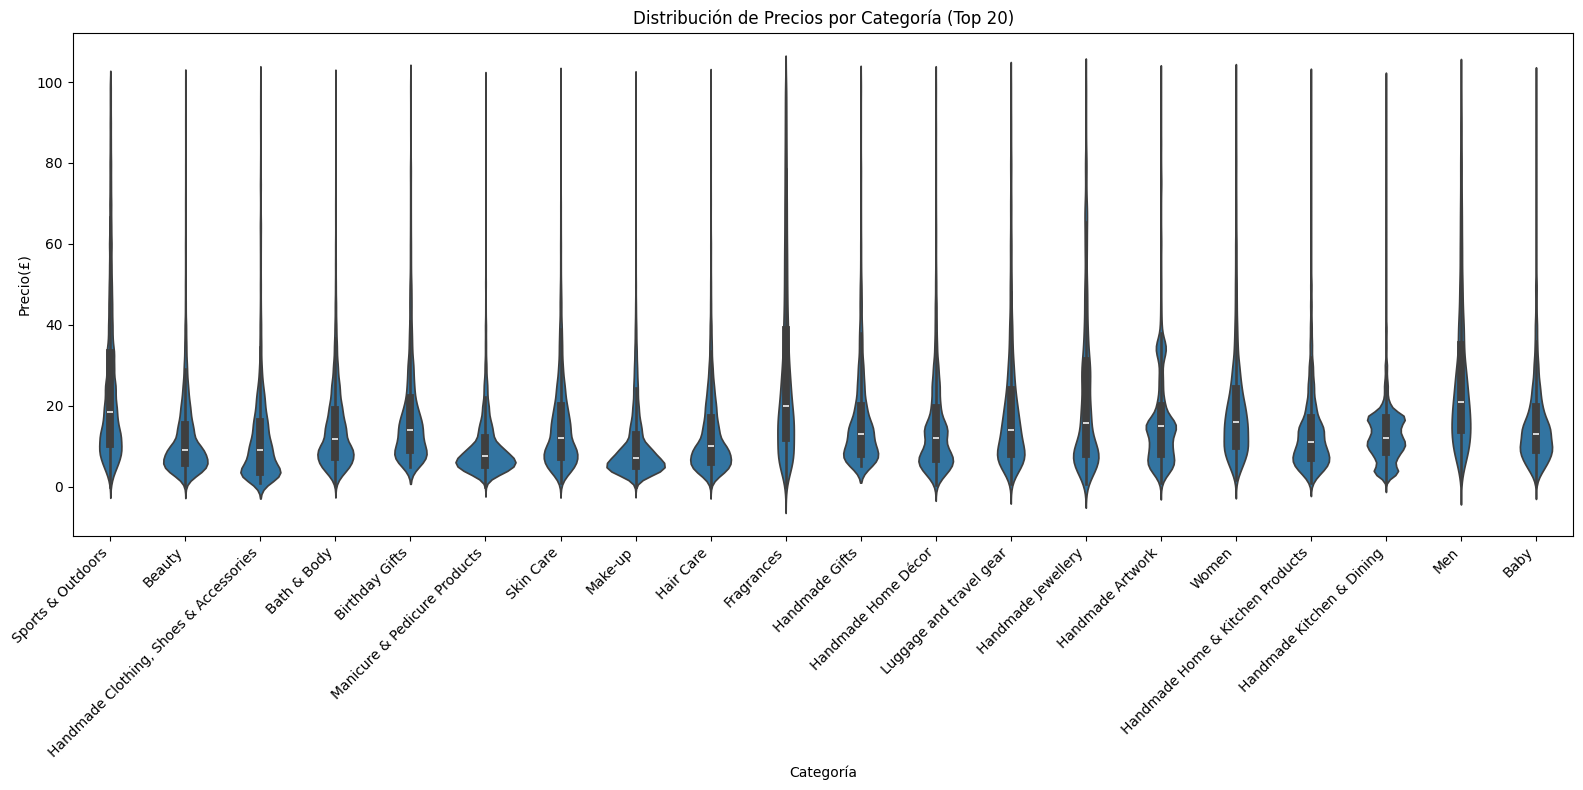

In [14]:
#top 20 categorías por count
top20_count = df['category'].value_counts().head(20).index

#filtrar

df_top20= df_no_outliers[df_no_outliers['category'].isin(top20_count)]

#Violin plot
plt.figure(figsize=(16, 8))
sns.violinplot(x='category', y='price', data=df_top20, order=top20_count)
plt.title('Distribución de Precios por Categoría (Top 20)')
plt.xlabel('Categoría')
plt.ylabel('Precio(£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
median_by_category = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
print(median_by_category.head(10))

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64


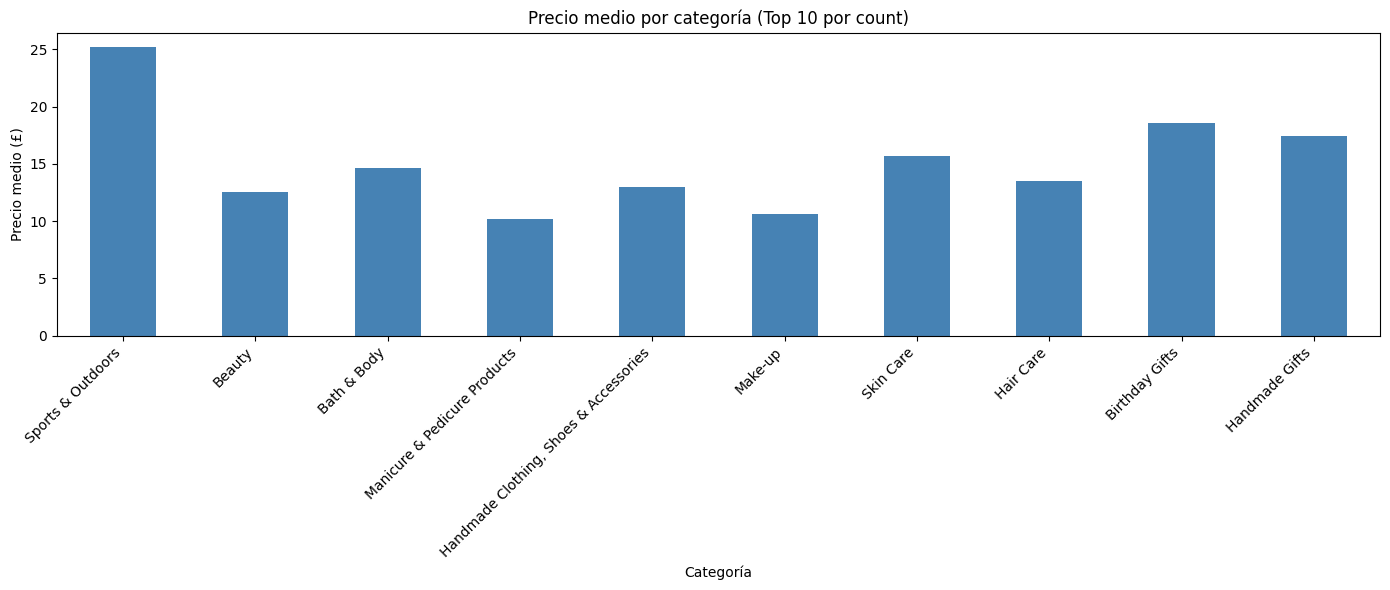

In [22]:
avg_price = df_top10.groupby('category')['price'].mean().reindex(top10_count)

plt.figure(figsize=(14, 6))
avg_price.plot(kind='bar', color='steelblue')
plt.title('Precio medio por categoría (Top 10 por count)')
plt.xlabel('Categoría')
plt.ylabel('Precio medio (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [24]:
df_no_outliers.groupby('category')['price'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False).head(10)

,mean,median,std
category,,,
Motherboards,68.772432,67.92,20.632565
Boxing Shoes,67.417803,69.79,18.752522
Desktop PCs,66.915562,74.00,28.167505
Tablets,66.552971,69.00,25.390369
Graphics Cards,65.103509,68.54,22.594322
Digital Frames,60.745129,63.90,26.083094
Streaming Clients,60.241803,62.68,20.246098
Hockey Shoes,60.094796,57.80,18.503307
Computer Cases,58.339884,54.99,23.116631


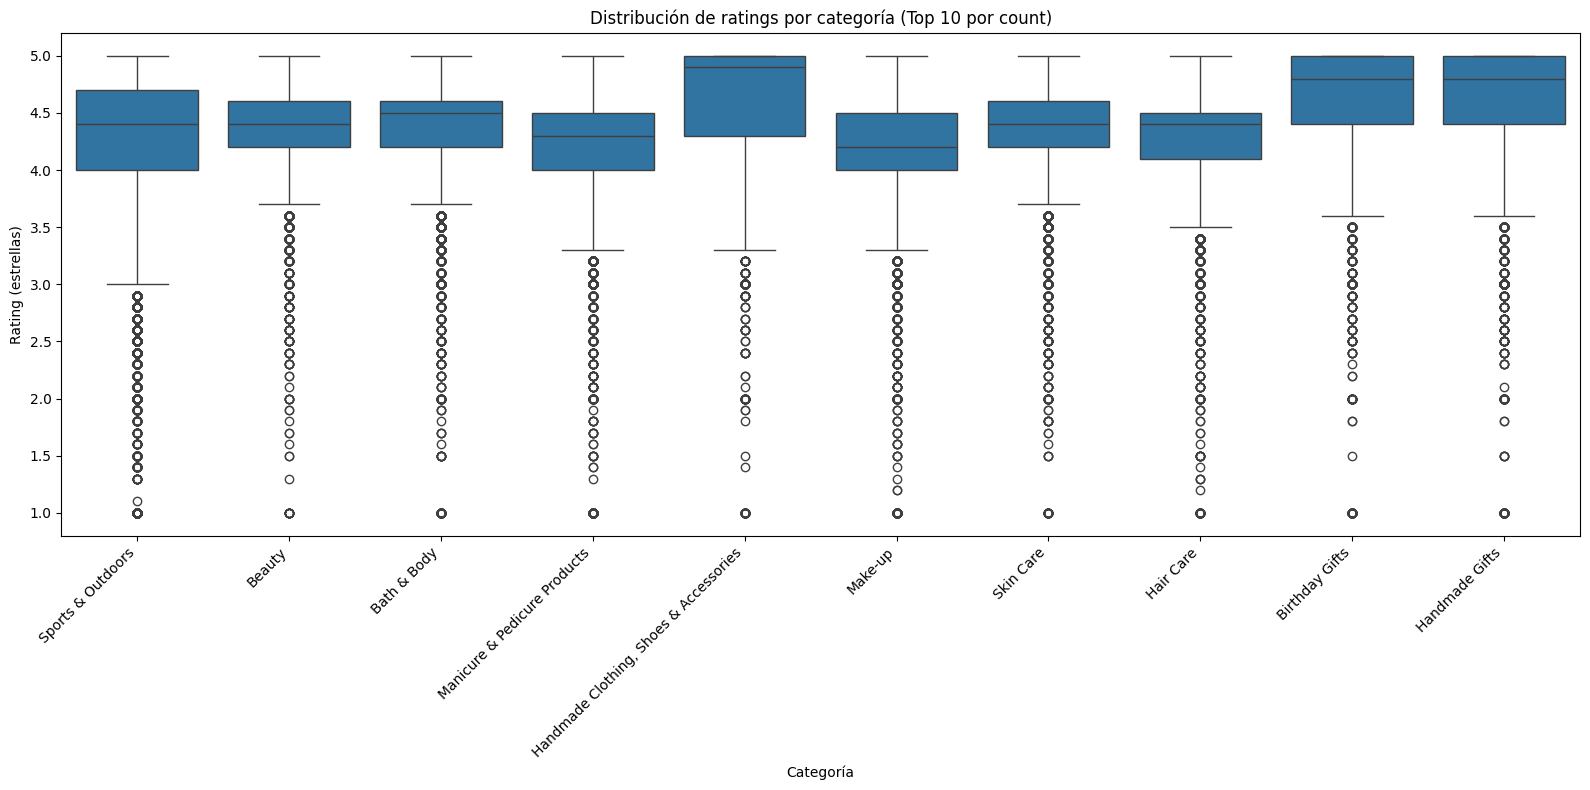

In [29]:
# Violin plot para las 10 categorías con mayor precio medio
df_rated = df_no_outliers[df_no_outliers['stars'] > 0]
df_top10_box = df_rated[df_rated['category'].isin(top10_count)]

plt.figure(figsize=(16, 8))
sns.boxplot(x='category', y='stars', data=df_top10_box, order=top10_count)
plt.title('Distribución de ratings por categoría (Top 10 por count)')
plt.xlabel('Categoría')
plt.ylabel('Rating (estrellas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# Mediana más alta
med = df_no_outliers.groupby('category')['stars'].median().sort_values(ascending=False).head(1)
print(med)

category
Computer Memory    4.7
Name: stars, dtype: float64


Podemos apreciar que, tras aplicar el IQR, los percentiles más altos y más bajos tienen una gran incidencia sobre el resto de precios, ya que estos percentiles representan el 13,4% del total. Por otra parte, y tras analizarlo en profundidad, la categoría con la mediana más alta es *Desktop PCs*, lo cual tiene sentido al tratarse de productos tecnológicos de alto valor. Del mismo modo, la categoría con el precio medio más alto es *Motherboards*, algo coherente debido a que son componentes tecnológicos con un coste elevado.

En el top 10 por *count*, la categoría con el precio más alto es *Sports & Outdoors*. En relación con las valoraciones, la categoría más sobresaliente es *Computer Memory*, con una media de 4,7 estrellas sobre 5. Además, dentro del top 10 por *count*, *Birthday Gifts* y *Handmade Gifts* presentan las medianas de rating más altas (~4,7–4,8), aunque en general todas las categorías se encuentran muy bien valoradas, con puntuaciones comprendidas entre 4,2 y 4,8 estrellas.

A nivel de negocio, estos insights permiten identificar categorías especialmente atractivas para nuevos vendedores. Por ejemplo, categorías como *Computer Memory* combinan valoraciones muy altas con una percepción positiva por parte de los consumidores, lo que puede facilitar la entrada al mercado y la generación de confianza. Por otro lado, categorías como *Desktop PCs* o *Motherboards* presentan precios elevados, lo que puede traducirse en mayores márgenes de beneficio, aunque también implican una mayor competencia y barreras de entrada. Asimismo, se puede observar que no siempre existe una relación directa entre precio alto y rating alto, ya que algunas categorías con precios más accesibles obtienen mejores valoraciones medias. Esto sugiere que la satisfacción del cliente depende no solo del valor económico del producto, sino también de factores como la calidad percibida, la experiencia de uso y las expectativas del consumidor.


In [33]:
#Calcular la correlación entre precio y estrellas
correlation = df_no_outliers['price'].corr(df_no_outliers['stars'])
print(f"Correlación entre precio y estrellas: {correlation:.4f}")

Correlación entre precio y estrellas: -0.0777


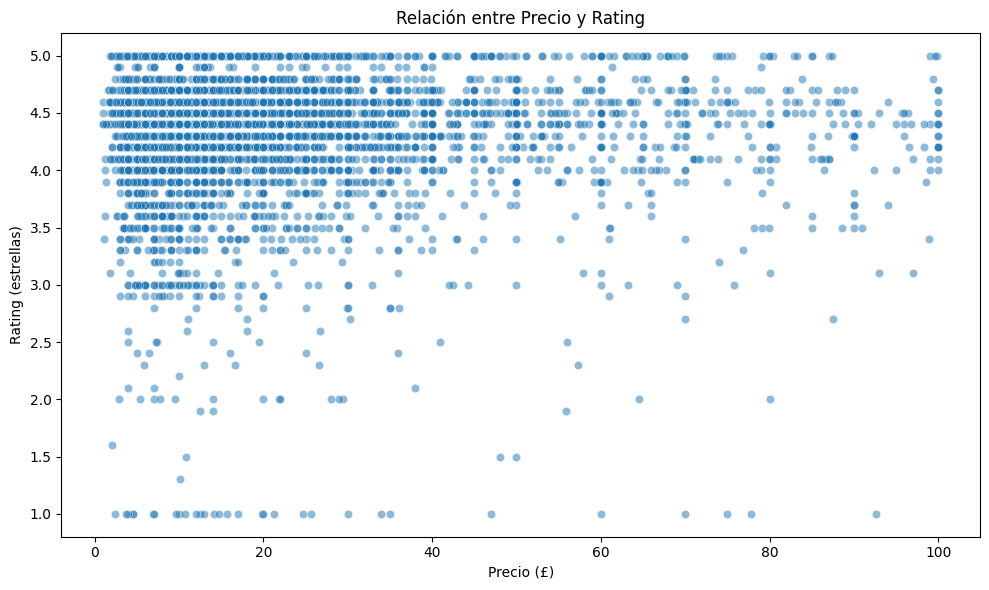

In [36]:
#Crear un scatter plot de precio vs estrellas
sample=df_rated.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='stars', data=sample, alpha=0.5)
plt.title('Relación entre Precio y Rating')
plt.xlabel('Precio (£)')
plt.ylabel('Rating (estrellas)')
plt.tight_layout()
plt.show()

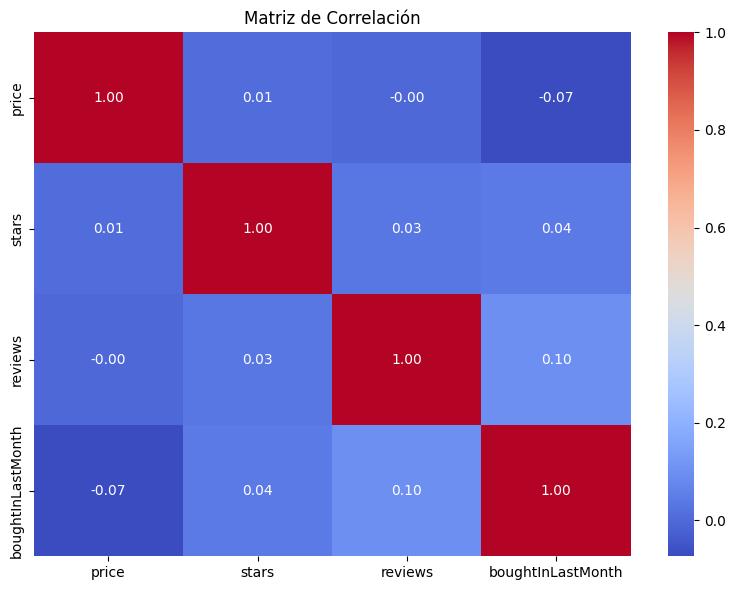

In [41]:
#Heatmap de correlación entre variables numéricas
corr_matrix = df_rated[['price', 'stars', 'reviews', 'boughtInLastMonth']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

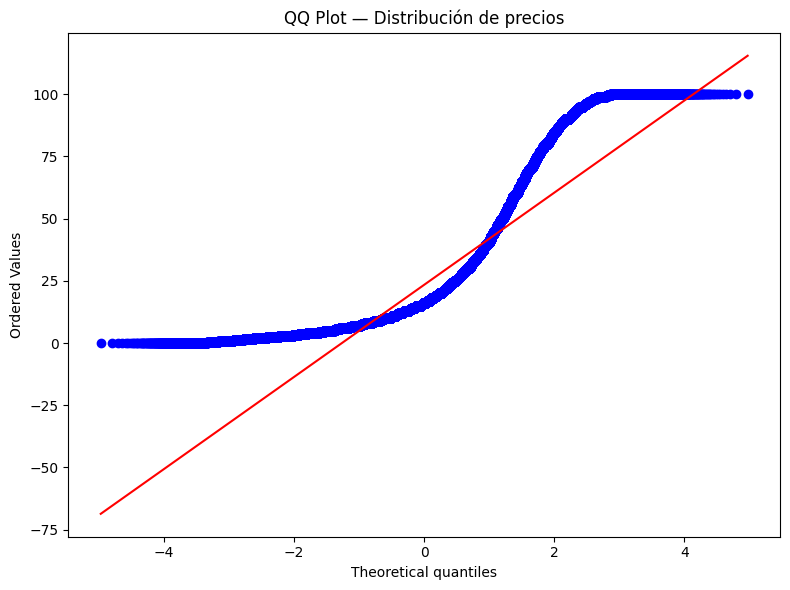

In [42]:
from scipy import stats

plt.figure(figsize=(8, 6))
stats.probplot(df_no_outliers['price'], dist="norm", plot=plt)
plt.title('QQ Plot — Distribución de precios')
plt.tight_layout()
plt.show()

En el análisis de correlación entre precio y rating se observa un coeficiente de -0.0777, lo que indica una correlación negativa muy débil y prácticamente nula. Esto significa que el precio apenas influye en la valoración de los productos, por lo que un producto más caro no garantiza necesariamente mejores opiniones por parte de los consumidores.
El scatter plot refuerza esta conclusión, ya que no se aprecia un patrón claro entre ambas variables. La mayoría de los productos con mejores valoraciones, situadas entre 4.0 y 5.0 estrellas, se concentran principalmente en el rango de precios entre £0 y £40. Esto sugiere que los consumidores tienden a valorar positivamente productos accesibles siempre que cumplan con sus expectativas de calidad y funcionalidad.
Por otro lado, el heatmap muestra que la correlación más destacada del dataset se produce entre el número de reviews y las compras realizadas en el último mes (boughtInLastMonth), con un valor de 0.10. Aunque no es una correlación muy alta, sí refleja que los productos con mayor volumen de compras generan más reseñas y, por tanto, una mayor interacción por parte de los usuarios. Además, el precio presenta una correlación negativa con las compras recientes (-0.07), lo que indica que los productos más caros tienden a comprarse con menor frecuencia.
En relación con la distribución de los precios, el QQ Plot demuestra que estos no siguen una distribución normal. Existe una asimetría positiva clara: la mayoría de los productos tienen precios bajos, mientras que solo una pequeña parte alcanza precios muy elevados, generando una cola larga hacia la derecha.
Desde una perspectiva de negocio, estos resultados sugieren que competir únicamente mediante precios altos no asegura una mejor percepción del producto ni mayores ventas. Las empresas podrían centrarse en ofrecer productos con buena relación calidad-precio dentro de rangos accesibles, donde se concentra la mayor parte de productos bien valorados. Asimismo, fomentar el volumen de ventas puede ayudar a incrementar el número de reviews, mejorando la visibilidad y credibilidad del producto en la plataforma. Finalmente, las categorías de precio elevado pueden resultar rentables por margen, pero requieren estrategias de diferenciación y confianza más sólidas debido a su menor frecuencia de compra.